# TRANSPORT DEMAND PREDICTION USING REGRESSION 

#### PROBLEM STATEMENT

Mobiticket, a bus/shuttle ticketing service, wants to accurately predict the number of seats sold for each of its scheduled rides. These rides operate from multiple towns to Nairobi, and travel demand varies by time, location, and other factors.

Objective:

Build a regression model that can predict the number of seats that will be sold for each ride (ride_id), based on:

Route details (travel_from, car_type, etc.)

Schedule info (travel_date, travel_time)

Capacity of the vehicle (max_capacity)

Temporal patterns (e.g., weekdays, month, time of day)

#### IMPORTING LIBRARIES

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

#### LOADING DATASET 

In [38]:
raw_df = pd.read_csv('train_revised.csv')

In [39]:
raw_df.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [40]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51645 entries, 0 to 51644
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ride_id          51645 non-null  int64 
 1   seat_number      51645 non-null  object
 2   payment_method   51645 non-null  object
 3   payment_receipt  51645 non-null  object
 4   travel_date      51645 non-null  object
 5   travel_time      51645 non-null  object
 6   travel_from      51645 non-null  object
 7   travel_to        51645 non-null  object
 8   car_type         51645 non-null  object
 9   max_capacity     51645 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 3.9+ MB


In [41]:
raw_df.shape

(51645, 10)

#### DESCCRIPTIVE STATISTICS

In [42]:
raw_df.describe(include="all")

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
count,51645.000000,51645,51645,51645,51645,51645,51645,51645,51645,51645.000000
unique,NaN,61,2,51645,149,78,17,1,2,NaN
top,NaN,1,Mpesa,UZUEHCBUSO,10-12-17,7:09,Kisii,Nairobi,Bus,NaN
freq,NaN,2065,51532,1,856,3926,22607,51645,31985,NaN
mean,10188.645793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.534321
std,2211.295708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.451193
min,1442.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000
25%,8287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000
50%,10353.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000
75%,12029.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000


Most rides use Buses with 49 seats.

Kisii to Nairobi is the most common route.

Most buses depart around 7:00 AM.

payment_receipt is a high-cardinality unique identifier.

payment_method has very low variability.

#### DATA INSPECTION AND CLEANING

In [43]:
print("Missing Values:\n",raw_df.isnull().sum())

Missing Values:
 ride_id            0
seat_number        0
payment_method     0
payment_receipt    0
travel_date        0
travel_time        0
travel_from        0
travel_to          0
car_type           0
max_capacity       0
dtype: int64


No null values are present in the dataset

#### DATA AGGREGATION

In [44]:
agg_df = raw_df.groupby(['ride_id', 'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type', 'max_capacity']).agg({'seat_number': 'count'}).reset_index()
agg_df.rename(columns={'seat_number': 'Seats_Sold'}, inplace=True)
print("Aggregated Shape:", df.shape)

Aggregated Shape: (6249, 11)


In [45]:
agg_df.head()

,ride_id,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,Seats_Sold
0,1442,17-10-17,7:15,Migori,Nairobi,Bus,49,1
1,5437,19-11-17,7:12,Migori,Nairobi,Bus,49,1
2,5710,26-11-17,7:05,Keroka,Nairobi,Bus,49,1
3,5777,27-11-17,7:10,Homa Bay,Nairobi,Bus,49,5
4,5778,27-11-17,7:12,Migori,Nairobi,Bus,49,31


#### FEATURE ENGINEERING 

In [46]:
#convert date and time
agg_df['travel_date'] = pd.to_datetime(agg_df['travel_date'], format='%d-%m-%y')
agg_df['Year'] = agg_df['travel_date'].dt.year
agg_df['Month'] = agg_df['travel_date'].dt.month
agg_df['Day'] = agg_df['travel_date'].dt.day
agg_df['Weekday'] = agg_df['travel_date'].dt.weekday

# Convert travel_time to hour
agg_df['Hour'] = agg_df['travel_time'].apply(lambda x: int(str(x).split(':')[0]))


In [47]:
# Drop original date/time columns
agg_df.drop(['travel_date', 'travel_time'], axis=1, inplace=True)

In [48]:
agg_df.head()

,ride_id,travel_from,travel_to,car_type,max_capacity,Seats_Sold,Year,Month,Day,Weekday,Hour
0,1442,Migori,Nairobi,Bus,49,1,2017,10,17,1,7
1,5437,Migori,Nairobi,Bus,49,1,2017,11,19,6,7
2,5710,Keroka,Nairobi,Bus,49,1,2017,11,26,6,7
3,5777,Homa Bay,Nairobi,Bus,49,5,2017,11,27,0,7
4,5778,Migori,Nairobi,Bus,49,31,2017,11,27,0,7


#### EXPLORATORY DATA ANALYSIS (EDA)

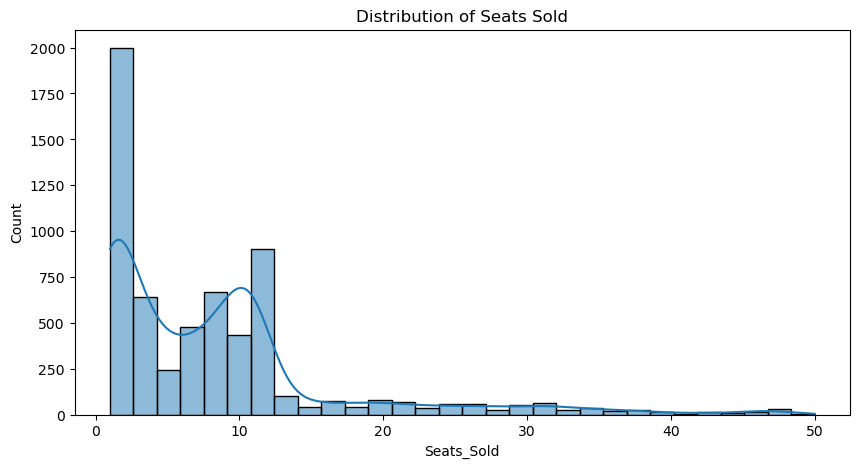

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(agg_df['Seats_Sold'], bins=30, kde=True)
plt.title('Distribution of Seats Sold')
plt.show()

Right-skewed distribution → Most rides sell very few seats (1–5).

Few high-demand rides → Some rides nearly sold out (40–50 seats).

Possible multiple demand patterns → Peaks around 1–2, 5–6, and 10 seats.

Long tail → Rare cases of very high demand.

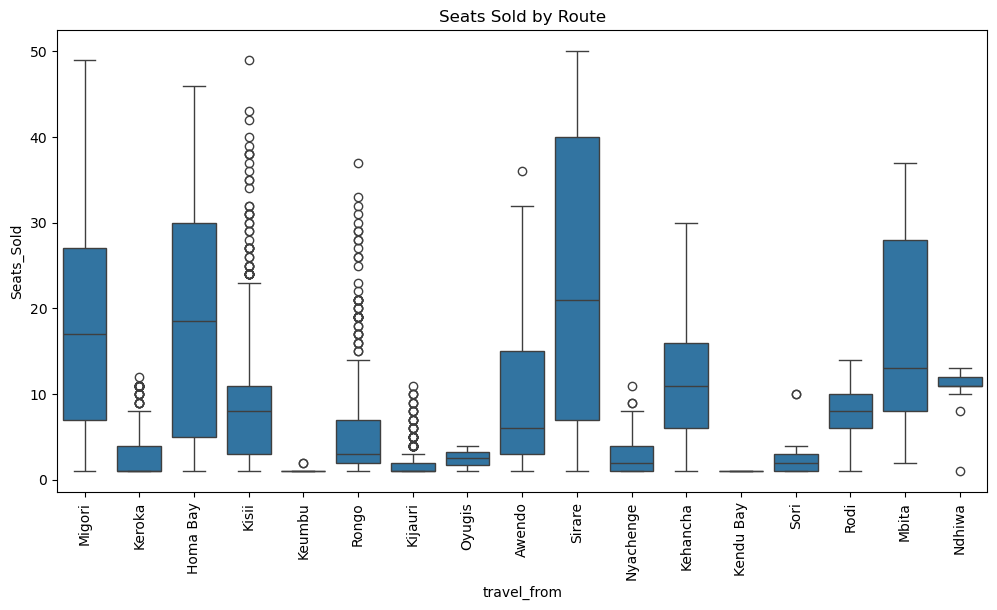

In [50]:
plt.figure(figsize=(12,6))
sns.boxplot(x='travel_from', y='Seats_Sold', data=agg_df)
plt.xticks(rotation=90)
plt.title('Seats Sold by Route')
plt.show()

High variability across routes → Some routes have consistently high demand, others very low.

Top demand routes → Sirare, Migori, and Homa Bay show the highest median and upper quartile.

Low demand routes → Oyugis, Kijauri, and Kendu Bay have very low median seats sold.

Outliers present → Many routes have outliers indicating occasional spikes in demand.

In [59]:
agg_df.to_csv('aggregated.csv', index=False)

#### LABEL ENCODING

In [51]:
cat_cols = ['travel_from', 'travel_to', 'car_type']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [52]:
df.head()

,ride_id,travel_from,travel_to,car_type,max_capacity,Seats_Sold,Year,Month,Day,Weekday,Hour
0,1442,16,0,0,49,1,2017,10,17,1,7
1,5437,16,0,0,49,1,2017,11,19,6,7
2,5710,11,0,0,49,1,2017,11,26,6,7
3,5777,1,0,0,49,5,2017,11,27,0,7
4,5778,16,0,0,49,31,2017,11,27,0,7


#### TEST-TRAIN SPLIT

In [54]:
# Define features and target
X = df.drop(['Seats_Sold', 'ride_id'], axis=1)
y = df['Seats_Sold']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### MODEL TRAINING

In [56]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgbr = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)

# Model Evaluation
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [evaluate_model(y_test, y_pred_lr)[0], evaluate_model(y_test, y_pred_rf)[0], evaluate_model(y_test, y_pred_xgb)[0]],
    'RMSE': [evaluate_model(y_test, y_pred_lr)[1], evaluate_model(y_test, y_pred_rf)[1], evaluate_model(y_test, y_pred_xgb)[1]],
    'R2 Score': [evaluate_model(y_test, y_pred_lr)[2], evaluate_model(y_test, y_pred_rf)[2], evaluate_model(y_test, y_pred_xgb)[2]]
})
print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  6.115893  8.498456  0.110684
1      Random Forest  4.510896  7.392849  0.327024
2            XGBoost  4.361895  7.016872  0.393734


#### FEATURE IMPORTANCE

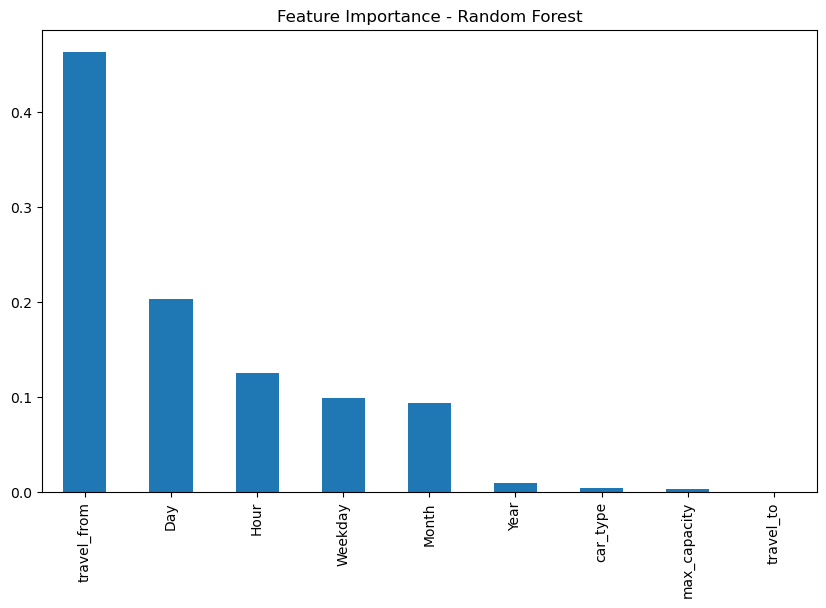

In [57]:
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,6), title='Feature Importance - Random Forest')
plt.show()

Top feature: travel_from is the most influential factor for seat demand.

Date-related features matter: Day, Hour, Weekday, and Month have moderate importance → demand depends on when people travel.

Year has minimal impact → data might be from a single year or stable across years.

Low impact features: car_type, max_capacity, and travel_to contribute very little.

#### SAVING PREDICTIONS 

In [58]:
y_test_pred_df = pd.DataFrame({'Actual': y_test, 'Predicted_RF': y_pred_rf, 'Predicted_XGB': y_pred_xgb})
y_test_pred_df.to_csv('predictions.csv', index=False)
print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv
